# Display Test Accuracy

In [42]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat

from matplotlib import pyplot as plt
from plots_utils.loading import parse_tf_events_file
import numpy as np
import pandas as pd

from pathlib import Path
import os

_old = ['gaussian-corr-ft-35', 'gaussian-corr-ft-50', 'gaussian-uncorr-ft-35', 'gaussian-uncorr-ft-50']
_tr = {'gaussian-corr-ft-35':'gp-35-tcsu-10ft', 'gaussian-corr-ft-50':'gp-50-tcsu-10ft', 'gaussian-uncorr-ft-35':'gp-35-tusu-10ft', 'gaussian-uncorr-ft-50':'gp-50-tusu-10ft'}

In [43]:
def get_exp_stats(config):
    results = list()
    for lr in config.lr_list:
        # time_horizon = time_horizons[p]  
        for algorithm in config.algorithms:
            # b_loop = config.b_values if algorithm == 'mixture' else [None] # in case we vary beta
            # for b in b_loop:
            for event in config.events:
                for seed in config.seeds:
                    for a in config.alphas:
                        for n_c in config.n_clients_list:
                            for av in config.availabilities:
                                for part in config.participations:
                                    for biased in config.biased_list:

                                        event_dir = config.get_event_dir(algorithm, lr, seed, 
                                                                            event, a, n_c, av, 
                                                                            config.n_rounds, part, biased, config.train_test) 


                                        if os.path.exists(event_dir):
                                            # print('x')
                                            # _, values = parse_tf_events_file(event_dir, tag="Test/Metric", time_horizon=time_horizon)
                                            _, test_accuracy_values = parse_tf_events_file(event_dir, tag="Test/Metric")
                                            _, test_loss_values = parse_tf_events_file(event_dir, tag="Test/Loss")
                                            _, train_accuracy_values = parse_tf_events_file(event_dir, tag="Train/Metric")
                                            _, train_loss_values = parse_tf_events_file(event_dir, tag="Train/Loss")
                                            ### tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'
                                            max_accuracy = np.array(test_accuracy_values).max() * 100
                                            results.append({
                                                "algorithm": algorithm, 
                                                "availability": _tr[av] if av in _old else av,
                                                "alpha": a, 
                                                "participation": part,
                                                "max_test_accuracy": float(max_accuracy),
                                                "final_test_accuracy":test_accuracy_values[-1]*100,
                                                "test_accuracy": np.array(test_accuracy_values),
                                                "seed": seed,
                                                "lr": lr, "event": event, "n_clients": n_c,
                                                "biased": biased
                                            })

                                            # "b": float(b) if b else np.nan # in case we vary beta
    return pd.DataFrame(results)

In [44]:
# config = ExperimentConfig(
#     base_path=os.path.join("..", "logs"),
#     experiment="mnist",
#     seeds=["42", "78", "84"],
#     algorithms=["fedavg", "fedvarp"],
#     events=["global"],
#     lr_list=["1e-1", "5e-2", "1e-2", "1e-3", "1e-4"],
#     alphas=["0.1"],
#     n_clients_list=["7"],
#     availabilities=list(
#         "gaussian-corr-ft-35 gaussian-corr-ft-50 gaussian-uncorr-ft-35 gaussian-uncorr-ft-50 gp-35-tcsc-10ft-2 gp-35-tusc-10ft-2 gp-50-tcsc-10ft-2 gp-50-tusc-10ft-2 gp-20304050607080-tcsu-10ft gp-20304050607080-tusu-10ft gp-25255050507575-tcsu-10ft gp-25255050507575-tusu-10ft".split(
#             " "
#         )
#     ),
#     n_rounds="100",
#     participations=["known"],
#     biased_list=["2"],
#     train_test="train",
# )

main_folder = 'correlation_experiments_50rounds'
config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="mnist_sp", seeds=["78", "84"],
                          algorithms=["fedavg"], events=["global"],
                          lr_list=["5e-2"], alphas=["0.5"], n_clients_list=["7"],
                          availabilities=[
# "gp50-50-tusu-3ft", 
# "gp50-50-tcsc-3ft", 
# "gp50-50-tcsu-3ft", 
# "gp50-50-tusc-3ft", 
# "gp50-35-tusu-3ft", 
# "gp50-35-tcsc-3ft", 
# "gp50-35-tcsu-3ft", 
# "gp50-35-tusc-3ft", 
# "gp50-25255050507575-tcsu-3ft", 
# "gp50-25255050507575-tusu-3ft", 
# "gp50-20304050607080-tcsu-3ft", 
# "gp50-20304050607080-tusu-3ft"
"gp50-50-tusu", 
"gp50-50-tcsc", 
"gp50-50-tcsu", 
"gp50-50-tusc", 
"gp50-35-tusu", 
"gp50-35-tcsc", 
"gp50-35-tcsu", 
"gp50-35-tusc", 
"gp50-25255050507575-tcsu", 
"gp50-25255050507575-tusu", 
"gp50-20304050607080-tcsu", 
"gp50-20304050607080-tusu"
],
                          n_rounds="50", participations=["known"], biased_list=["2"], train_test="train")


results_df = get_exp_stats(config)

In [45]:
tmp = results_df.groupby(['algorithm', 'availability','lr']).test_accuracy.apply(np.vstack).to_frame().reset_index()

In [46]:
tmp['mean_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.mean(axis=0))
tmp['var_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.var(axis=0))
tmp['mean_var_test_acc'] = tmp['var_test_acc'].apply(lambda x : x.mean())
tmp['final_mean_acc'] = tmp['mean_test_acc'].apply(lambda x : x[-1])
tmp['min_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.min(axis=0))
tmp['max_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.max(axis=0))

tmp

,algorithm,availability,lr,test_accuracy,mean_test_acc,var_test_acc,mean_var_test_acc,final_mean_acc,min_test_acc,max_test_acc
0,fedavg,gp50-20304050607080-tcsu,5e-2,"[[0.1436000019311905, 0.7276999950408936, 0.84...","[0.10545000061392784, 0.7294999957084656, 0.84...","[0.001455422600507142, 3.240002403259723e-06, ...",0.000039,0.98560,"[0.06729999929666519, 0.7276999950408936, 0.84...","[0.1436000019311905, 0.7312999963760376, 0.848..."
1,fedavg,gp50-20304050607080-tusu,5e-2,"[[0.1436000019311905, 0.6126000285148621, 0.74...","[0.10545000061392784, 0.6144500076770782, 0.77...","[0.001455422600507142, 3.4224229006341034e-06,...",0.000059,0.98680,"[0.06729999929666519, 0.6126000285148621, 0.74...","[0.1436000019311905, 0.6162999868392944, 0.811..."
2,fedavg,gp50-25255050507575-tcsu,5e-2,"[[0.1436000019311905, 0.445499986410141, 0.793...","[0.10545000061392784, 0.44804999232292175, 0.7...","[0.001455422600507142, 6.502530155216846e-06, ...",0.000066,0.98205,"[0.06729999929666519, 0.445499986410141, 0.744...","[0.1436000019311905, 0.4505999982357025, 0.793..."
3,fedavg,gp50-25255050507575-tusu,5e-2,"[[0.1436000019311905, 0.2955999970436096, 0.50...","[0.10545000061392784, 0.2990500032901764, 0.58...","[0.001455422600507142, 1.190254310134975e-05, ...",0.000152,0.98150,"[0.06729999929666519, 0.2955999970436096, 0.50...","[0.1436000019311905, 0.30250000953674316, 0.65..."
4,fedavg,gp50-35-tcsc,5e-2,"[[0.1436000019311905, 0.5814999938011169, 0.78...","[0.10545000061392784, 0.5728499889373779, 0.78...","[0.001455422600507142, 7.482258414270859e-05, ...",0.000077,0.98335,"[0.06729999929666519, 0.5641999840736389, 0.77...","[0.1436000019311905, 0.5814999938011169, 0.782..."
5,fedavg,gp50-35-tcsu,5e-2,"[[0.1436000019311905, 0.6486999988555908, 0.63...","[0.10545000061392784, 0.6385500133037567, 0.64...","[0.001455422600507142, 0.00010302220670244111,...",0.000053,0.98440,"[0.06729999929666519, 0.6284000277519226, 0.63...","[0.1436000019311905, 0.6486999988555908, 0.651..."
6,fedavg,gp50-35-tusc,5e-2,"[[0.1436000019311905, 0.1436000019311905, 0.14...","[0.10545000061392784, 0.10545000061392784, 0.1...","[0.001455422600507142, 0.001455422600507142, 0...",0.000199,0.98650,"[0.06729999929666519, 0.06729999929666519, 0.0...","[0.1436000019311905, 0.1436000019311905, 0.143..."
7,fedavg,gp50-35-tusu,5e-2,"[[0.1436000019311905, 0.5340999960899353, 0.80...","[0.10545000061392784, 0.5801999866962433, 0.84...","[0.001455422600507142, 0.0021252091339016843, ...",0.000114,0.98035,"[0.06729999929666519, 0.5340999960899353, 0.80...","[0.1436000019311905, 0.6262999773025513, 0.886..."
8,fedavg,gp50-50-tcsc,5e-2,"[[0.1436000019311905, 0.5368000268936157, 0.58...","[0.10545000061392784, 0.5329500138759613, 0.59...","[0.001455422600507142, 1.4822600236108485e-05,...",0.000050,0.98835,"[0.06729999929666519, 0.5291000008583069, 0.58...","[0.1436000019311905, 0.5368000268936157, 0.602..."
9,fedavg,gp50-50-tcsu,5e-2,"[[0.1436000019311905, 0.6208999752998352, 0.70...","[0.10545000061392784, 0.5743499994277954, 0.75...","[0.001455422600507142, 0.002166900253687487, 0...",0.000132,0.98875,"[0.06729999929666519, 0.5278000235557556, 0.70...","[0.1436000019311905, 0.6208999752998352, 0.804..."


,algorithm,availability,lr,mean_var_test_acc
0,fedavg,gp50-20304050607080-tcsu,5e-2,0.000039
1,fedavg,gp50-20304050607080-tusu,5e-2,0.000059
2,fedavg,gp50-25255050507575-tcsu,5e-2,0.000066
3,fedavg,gp50-25255050507575-tusu,5e-2,0.000152
4,fedavg,gp50-35-tcsc,5e-2,0.000077
5,fedavg,gp50-35-tcsu,5e-2,0.000053
6,fedavg,gp50-35-tusc,5e-2,0.000199
7,fedavg,gp50-35-tusu,5e-2,0.000114
8,fedavg,gp50-50-tcsc,5e-2,0.000050
9,fedavg,gp50-50-tcsu,5e-2,0.000132


['gp50-20304050607080-tcsu', 'gp50-20304050607080-tusu', 'gp50-25255050507575-tcsu', 'gp50-25255050507575-tusu', 'gp50-35-tcsc', 'gp50-35-tcsu', 'gp50-35-tusc', 'gp50-35-tusu', 'gp50-50-tcsc', 'gp50-50-tcsu', 'gp50-50-tusc', 'gp50-50-tusu']


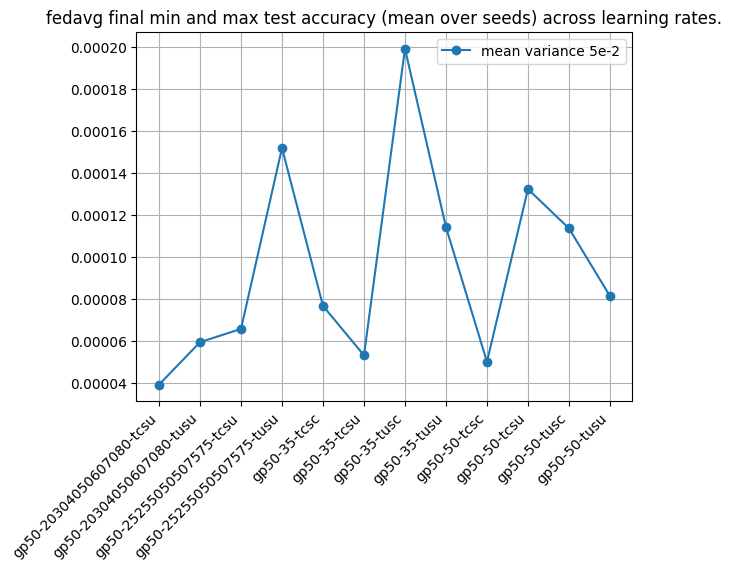

In [47]:
tmp_lr = tmp[['algorithm', 'availability', 'lr', 'mean_var_test_acc']]

display(tmp_lr)
x_values = [a.replace('gp-','').replace('-10ft', '') for a in tmp_lr.loc[(tmp_lr.lr=="5e-2")&(tmp_lr.algorithm=='fedavg'),'availability']]
print(x_values)
for algo in ['fedavg']:
    plt.figure()

    for lr in ["5e-2"]:
        plt.plot(x_values, tmp_lr[(tmp_lr.lr==lr)&(tmp_lr.algorithm==algo)]['mean_var_test_acc'], '-o', label='mean variance '+lr)

    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.title(algo+' final min and max test accuracy (mean over seeds) across learning rates.')
    plt.grid()

In [48]:
res_old = tmp.loc[tmp.groupby(['algorithm', 'availability'])['final_mean_acc'].idxmax()]

In [49]:
max_res = tmp.loc[tmp.groupby(['algorithm', 'availability'])['final_mean_acc'].idxmax()][['algorithm','availability','final_mean_acc']].rename(columns={'final_mean_acc': 'max_final_mean_acc'})
min_res = tmp.loc[tmp.groupby(['algorithm', 'availability'])['final_mean_acc'].idxmin()][['algorithm','availability','final_mean_acc']].rename(columns={'final_mean_acc': 'min_final_mean_acc'})

In [50]:
res_ = pd.merge(max_res, min_res, on=['algorithm', 'availability'], how='outer')

In [51]:
res_

,algorithm,availability,max_final_mean_acc,min_final_mean_acc
0,fedavg,gp50-20304050607080-tcsu,0.98560,0.98560
1,fedavg,gp50-20304050607080-tusu,0.98680,0.98680
2,fedavg,gp50-25255050507575-tcsu,0.98205,0.98205
3,fedavg,gp50-25255050507575-tusu,0.98150,0.98150
4,fedavg,gp50-35-tcsc,0.98335,0.98335
5,fedavg,gp50-35-tcsu,0.98440,0.98440
6,fedavg,gp50-35-tusc,0.98650,0.98650
7,fedavg,gp50-35-tusu,0.98035,0.98035
8,fedavg,gp50-50-tcsc,0.98835,0.98835
9,fedavg,gp50-50-tcsu,0.98875,0.98875


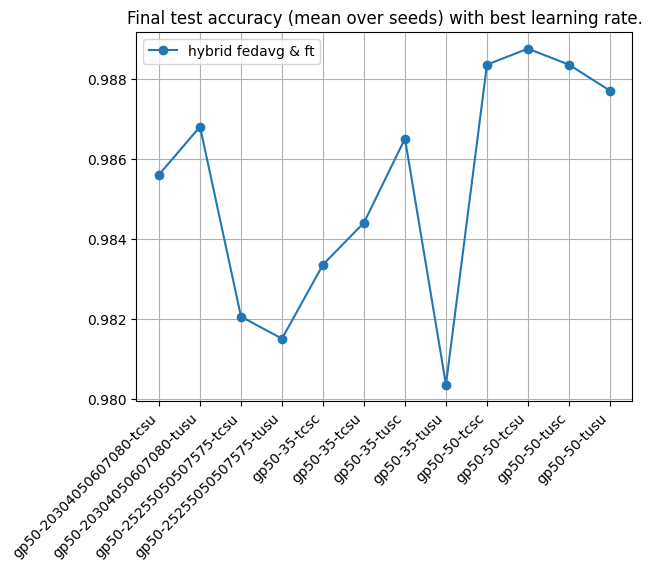

In [52]:
x_values = [a.replace('gp-','').replace('-10ft', '') for a in res_[res_.algorithm=='fedavg']['availability']]

plt.figure()
plt.plot(x_values, res_[res_.algorithm=='fedavg']['max_final_mean_acc'], '-o', label='hybrid fedavg & ft')
# plt.plot(x_values, res_[res_.algorithm=='fedvarp']['max_final_mean_acc'], '-o', label='hybrid fedvarp & ft')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.title('Final test accuracy (mean over seeds) with best learning rate.')
plt.grid()

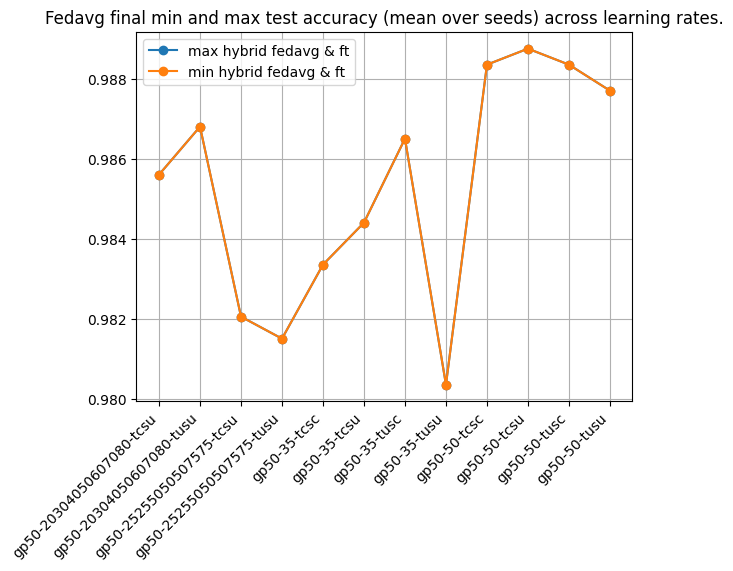

In [53]:
plt.figure()
plt.plot(x_values, res_[res_.algorithm=='fedavg']['max_final_mean_acc'], '-o', label='max hybrid fedavg & ft')
plt.plot(x_values, res_[res_.algorithm=='fedavg']['min_final_mean_acc'], '-o', label='min hybrid fedavg & ft')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.title('Fedavg final min and max test accuracy (mean over seeds) across learning rates.')
plt.grid()